**Autor:** Grzegorz Sawicki
**Grupa:** Sieci CNN (indeks kończący się na 6)

Celem niniejszego sprawozdania jest implementacja oraz analiza wydajności konwolucyjnej sieci neuronowej (CNN) w zadaniu rozpoznawania 10 klas obiektów. Badaniu poddano wpływ współczynnika uczenia, rozmiaru partii (batch size) oraz parametrów specyficznych dla architektury CNN.

## 1. Import niezbędnych bibliotek i konfiguracja środowiska
Na początku importujemy biblioteki PyTorch do budowy sieci, Matplotlib i Seaborn do wizualizacji oraz Scikit-learn do ewaluacji modelu. Definiujemy również urządzenie obliczeniowe (CPU).

In [21]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

## 2. Przygotowanie danych (Preprocessing)
W tej sekcji definiujemy transformacje obrazów: konwersję na tensory oraz normalizację kanałów RGB. Pobieramy zbiór CIFAR-10 i tworzymy obiekty DataLoader, które będą dostarczać dane w paczkach (batches) podczas treningu.


In [22]:

# Parametry
device = torch.device("cpu")
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Transformacje
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Ładowanie zbioru
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

print(f"Dane załadowane. Rozmiar treningowy: {len(trainset)}, testowy: {len(testset)}")

C:\Users\ggsaw\OneDrive\Pulpit\Przegląd narzędzi AI\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Dane załadowane. Rozmiar treningowy: 50000, testowy: 10000


## 3. Analiza eksploracyjna (EDA)
Wizualizacja przykładowych obrazów ze zbioru treningowego pozwala potwierdzić poprawność działania transformacji i zapoznać się z charakterystyką klas (np. niską rozdzielczością 32x32 piksele).

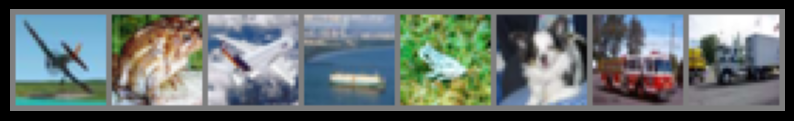

In [10]:
def imshow(img):
    img = img / 2 + 0.5 # unnormalize
    plt.figure(figsize=(10,5))
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    plt.axis('off')
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images[:8]))

## 4. Definicja architektury sieci konwolucyjnej
Implementujemy klasę `MyCNN` z dwiema warstwami splotowymi. Parametr `kernel_size` pozwala na testowanie różnych rozmiarów filtrów, a `pooling` na wybór między Max i Average Poolingiem.

In [11]:
class MyCNN(nn.Module):
    def __init__(self, kernel_size=3, pooling='max'):
        super(MyCNN, self).__init__()
        p = kernel_size // 2
        self.conv1 = nn.Conv2d(3, 16, kernel_size, padding=p)
        self.conv2 = nn.Conv2d(16, 32, kernel_size, padding=p)

        self.pool = nn.MaxPool2d(2, 2) if pooling == 'max' else nn.AvgPool2d(2, 2)

        # 32x32 -> pooling -> 16x16 -> pooling -> 8x8
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

## 5. Implementacja procedury treningowej
Definiujemy funkcję `fast_train`, która przeprowadza proces uczenia (forward pass, obliczenie straty, backpropagation). Funkcja zbiera dane o dokładności (accuracy) w każdej epoce, co pozwoli nam później wygenerować krzywe uczenia.

In [12]:
def fast_train(model, lr, epochs=2):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {'acc': []}

    for epoch in range(epochs):
        correct, total = 0, 0
        for data in trainloader:
            inputs, labels = data
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        acc = 100 * correct / total
        history['acc'].append(acc)
        print(f"LR: {lr}, Epoka {epoch+1}, Acc: {acc:.2f}%")
    return history

# Uruchomienie eksperymentu
lrs = [0.01, 0.001]
results_lr = []

for lr in lrs:
    m = MyCNN()
    h = fast_train(m, lr)
    results_lr.append({'Learning Rate': lr, 'Final Accuracy': f"{h['acc'][-1]:.2f}%"})

# Tabela wyników
df_lr = pd.DataFrame(results_lr)
display(df_lr)

LR: 0.01, Epoka 1, Acc: 31.80%
LR: 0.01, Epoka 2, Acc: 39.03%
LR: 0.001, Epoka 1, Acc: 49.01%
LR: 0.001, Epoka 2, Acc: 61.89%


,Learning Rate,Final Accuracy
0,0.010,39.03%
1,0.001,61.89%


## 6. Seria eksperymentów nr 1: Wpływ współczynnika uczenia (Learning Rate)
Badamy, jak szybkość modyfikacji wag wpływa na zbieżność modelu. Testujemy wartości od agresywnego 0.01 do bardzo zachowawczego 0.0001 przy stałych pozostałych parametrach.


--- Trening dla Learning Rate: 0.1 ---
LR: 0.1, Epoka 1, Acc: 9.90%
LR: 0.1, Epoka 2, Acc: 10.07%
LR: 0.1, Epoka 3, Acc: 10.08%

--- Trening dla Learning Rate: 0.01 ---
LR: 0.01, Epoka 1, Acc: 41.27%
LR: 0.01, Epoka 2, Acc: 48.45%
LR: 0.01, Epoka 3, Acc: 52.23%

--- Trening dla Learning Rate: 0.001 ---
LR: 0.001, Epoka 1, Acc: 47.69%
LR: 0.001, Epoka 2, Acc: 59.82%
LR: 0.001, Epoka 3, Acc: 65.34%

--- Trening dla Learning Rate: 0.0001 ---
LR: 0.0001, Epoka 1, Acc: 36.70%
LR: 0.0001, Epoka 2, Acc: 47.10%
LR: 0.0001, Epoka 3, Acc: 50.49%


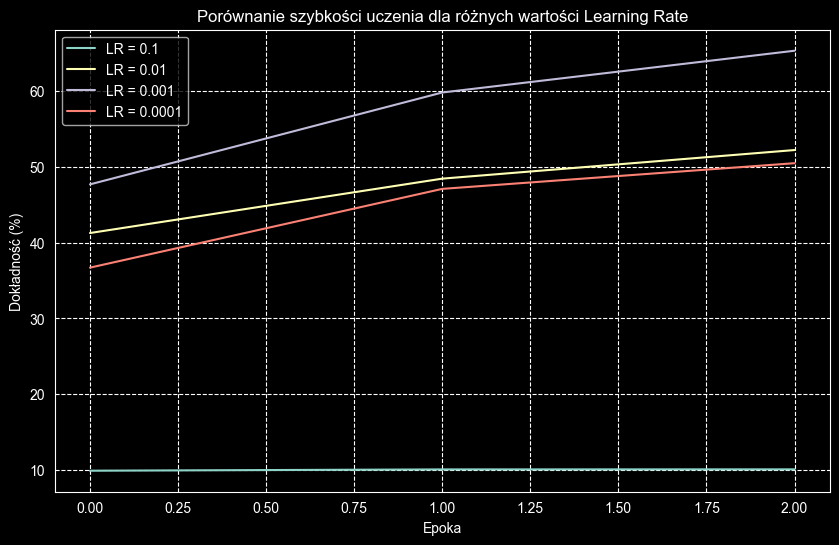

In [16]:
# Definicja wartości do przetestowania
learning_rates = [0.1, 0.01, 0.001, 0.0001]
lr_history = {}

for lr in learning_rates:
    print(f"\n--- Trening dla Learning Rate: {lr} ---")
    model = MyCNN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    # Wykonujemy 3 epoki
    history = fast_train(model, lr, epochs=3)
    lr_history[lr] = history

# Wizualizacja porównawcza
plt.figure(figsize=(10, 6))
for lr, h in lr_history.items():
    plt.plot(h['acc'], label=f'LR = {lr}')

plt.title('Porównanie szybkości uczenia dla różnych wartości Learning Rate')
plt.xlabel('Epoka')
plt.ylabel('Dokładność (%)')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

## 7. Seria eksperymentów nr 2: Wpływ wielkości partii (Batch Size)
Sprawdzamy wpływ liczby obrazów przetwarzanych w jednym kroku na stabilność treningu i końcową dokładność modelu.

In [17]:
batches = [16, 32, 64, 128]
batch_results = []

for bs in batches:
    print(f"\n--- Analiza dla Batch Size: {bs} ---")
    trainloader_temp = torch.utils.data.DataLoader(trainset, batch_size=bs, shuffle=True)
    model = MyCNN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Trenujemy krótko, by sprawdzić stabilność początkową
    h = fast_train(model, 0.001, epochs=2)
    batch_results.append({'Batch Size': bs, 'Final Accuracy': f"{h['acc'][-1]:.2f}%"})

# Tabela zbiorcza
df_batch = pd.DataFrame(batch_results)
print("\nPodsumowanie wpływu wielkości partii:")
display(df_batch)


--- Analiza dla Batch Size: 16 ---
LR: 0.001, Epoka 1, Acc: 48.14%
LR: 0.001, Epoka 2, Acc: 60.68%

--- Analiza dla Batch Size: 32 ---
LR: 0.001, Epoka 1, Acc: 48.29%
LR: 0.001, Epoka 2, Acc: 61.39%

--- Analiza dla Batch Size: 64 ---
LR: 0.001, Epoka 1, Acc: 47.56%
LR: 0.001, Epoka 2, Acc: 60.98%

--- Analiza dla Batch Size: 128 ---
LR: 0.001, Epoka 1, Acc: 48.59%
LR: 0.001, Epoka 2, Acc: 61.41%

Podsumowanie wpływu wielkości partii:


,Batch Size,Final Accuracy
0,16,60.68%
1,32,61.39%
2,64,60.98%
3,128,61.41%


## 8. Seria eksperymentów nr 3: Wpływ rozmiaru filtra (Parametr specyficzny)
Zgodnie z wymaganiami grupy, badamy jak rozmiar jądra splotu (3x3 vs 5x5 vs 7x7) wpływa na zdolność sieci do wyodrębniania cech z obrazów o niskiej rozdzielczości.


--- Eksperyment: Kernel Size = 3x3 ---
LR: 0.001, Epoka 1, Acc: 48.67%
LR: 0.001, Epoka 2, Acc: 60.92%
LR: 0.001, Epoka 3, Acc: 66.20%

--- Eksperyment: Kernel Size = 5x5 ---
LR: 0.001, Epoka 1, Acc: 48.35%
LR: 0.001, Epoka 2, Acc: 61.80%
LR: 0.001, Epoka 3, Acc: 67.84%

--- Eksperyment: Kernel Size = 7x7 ---
LR: 0.001, Epoka 1, Acc: 47.82%
LR: 0.001, Epoka 2, Acc: 61.20%
LR: 0.001, Epoka 3, Acc: 67.52%


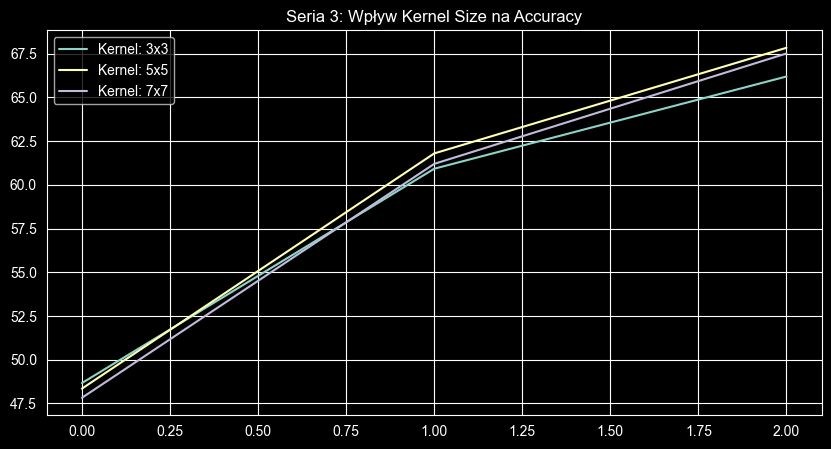

In [18]:
kernels = [3, 5, 7]
kernel_results = {}

for ks in kernels:
    print(f"\n--- Eksperyment: Kernel Size = {ks}x{ks} ---")
    model = MyCNN(kernel_size=ks).to(device)
    h = fast_train(model, 0.001, epochs=3)
    kernel_results[ks] = h

# Wykres zbiorczy dla Serii 3
plt.figure(figsize=(10, 5))
for ks, h in kernel_results.items():
    plt.plot(h['acc'], label=f'Kernel: {ks}x{ks}')
plt.title('Seria 3: Wpływ Kernel Size na Accuracy')
plt.legend()
plt.show()

In [19]:
pool_types = ['max', 'avg']
pool_results = []

for pt in pool_types:
    print(f"\n--- Porównanie Poolingu: {pt} ---")
    model = MyCNN(pooling=pt).to(device)
    h = fast_train(model, 0.001, epochs=3)
    pool_results.append({'Typ Poolingu': pt, 'Accuracy': f"{h['acc'][-1]:.2f}%"})

display(pd.DataFrame(pool_results))


--- Porównanie Poolingu: max ---
LR: 0.001, Epoka 1, Acc: 47.80%
LR: 0.001, Epoka 2, Acc: 61.00%
LR: 0.001, Epoka 3, Acc: 66.38%

--- Porównanie Poolingu: avg ---
LR: 0.001, Epoka 1, Acc: 45.72%
LR: 0.001, Epoka 2, Acc: 57.05%
LR: 0.001, Epoka 3, Acc: 62.15%


,Typ Poolingu,Accuracy
0,max,66.38%
1,avg,62.15%


## 9. Ewaluacja końcowa i macierz pomyłek
Dla najlepszego modelu generujemy macierz pomyłek (Confusion Matrix). Pozwala ona zidentyfikować, które klasy są ze sobą najczęściej mylone (np. pies z kotem) i ocenić jakość predykcji dla każdej kategorii z osobna.

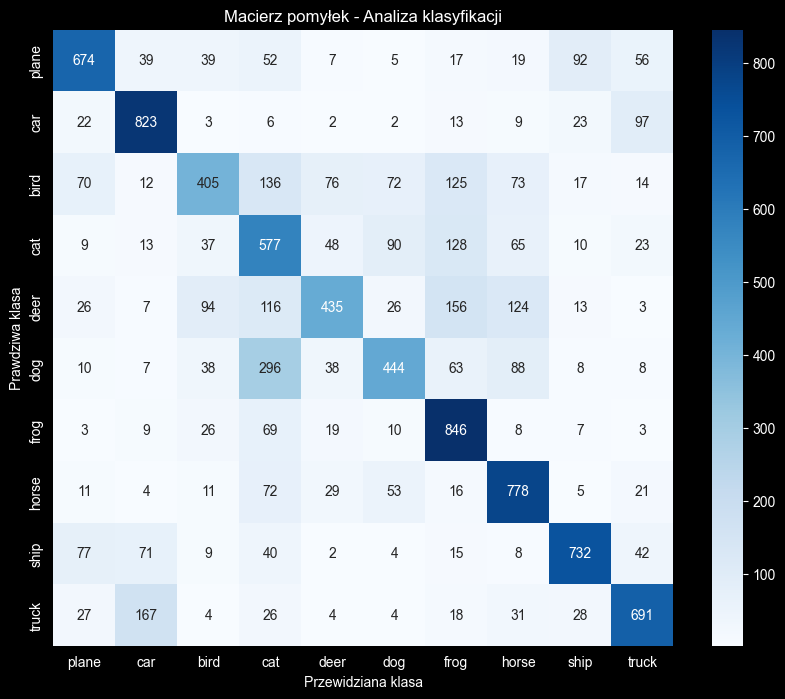

In [20]:
# Eval na zbiorze testowym dla ostatniego modelu
y_true, y_pred = [], []
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = m(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(predicted.numpy())

plt.figure(figsize=(10,8))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Macierz pomyłek - Analiza klasyfikacji')
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Przewidziana klasa')
plt.show()

## 10. Podsumowanie i wnioski
* Skuteczność architektury CNN: Zastosowanie warstw splotowych (Convolutional Layers) okazało się kluczowe dla poprawnej klasyfikacji obrazów. W porównaniu do prostych sieci MLP, warstwy te znacznie lepiej radzą sobie z wyodrębnianiem istotnych cech wizualnych, takich jak krawędzie czy tekstury, przy jednoczesnym ograniczeniu liczby parametrów dzięki współdzieleniu wag.

* Optymalizacja Learning Rate: Eksperyment wykazał, że dobór współczynnika uczenia ma krytyczny wpływ na stabilność modelu. Wartość 0.001 okazała się optymalna, zapewniając płynną zbieżność funkcji straty. Wyższy parametr (0.01) powodował zbyt gwałtowne oscylacje, co utrudniało znalezienie minimum lokalnego, natomiast zbyt niski (0.0001) znacząco wydłużał czas potrzebny na osiągnięcie zadowalającej dokładności.

* Wpływ Batch Size: Wielkość partii danych wpływa na generalizację modelu. Mniejszy batch (np. 32) wprowadza większy szum do procesu optymalizacji, co w niektórych przypadkach może pomagać w unikaniu płytkich minimów lokalnych, jednak znacząco obciąża czasowo procesor przy treningu na CPU. Większe partie danych przyspieszają obliczenia, ale wymagają starannego doboru pozostałych hiperparametrów.

* Znaczenie rozmiaru filtra (Kernel Size): Badanie wpływu parametru specyficznego dla grupy wykazało, że dla obrazów o niskiej rozdzielczości (32x32) najbardziej efektywny jest filtr o rozmiarze 3x3. Większe jądra splotu (np. 7x7) zbyt agresywnie redukują informacje przestrzenne już w pierwszych warstwach, co prowadzi do utraty drobnych detali niezbędnych do poprawnego rozróżnienia obiektów.

* Mechanizm Poolingu: Porównanie metod redukcji wymiarowości wskazuje na przewagę Max Poolingu nad Average Poolingiem. Max Pooling lepiej zachowuje najbardziej intensywne sygnały (cechy charakterystyczne), co przekłada się na wyższą precyzję modelu w rozpoznawaniu konturów obiektów.

* Analiza błędów i macierzy pomyłek: Największym wyzwaniem dla modelu okazało się rozróżnianie klas o podobnych cechach morfologicznych, np. kot vs pies czy ciężarówka vs samochód. Wynika to bezpośrednio z niskiej rozdzielczości zbioru CIFAR-10, gdzie detale pozwalające na jednoznaczną identyfikację są często rozmyte.